# Plot benchmark results (gata / gatav)

Walks every result file matched by `DATA_GLOB` and, for each one, draws an
ata plot, an atav plot, and prints the best-parameter tables.

Each input file is a combined output from running both `gata_example` and
`gatav_example` in the same job. Lines are dispatched to the ata or atav
bucket based on which `MPI_Alltoall(v)` (or `gata` / `gatav`) tag was last
seen.

**Aggregation across the 30 repetitions of each `(tag, n, params)`:**
1. **Outlier removal** — Tukey 1.5×IQR fence.
2. **Center** — median of the 30 runs.
3. **Error bars** — `[min, max]` of the surviving samples (asymmetric).

**Across parameters at the same `n`:** pick the params (`b` for
`MPICH-scattered`, `(b, r)` for `gata`/`gatav`) with the smallest median.

In [5]:
import glob
import os
import re
from collections import defaultdict
import matplotlib.pyplot as plt

# All result files matching this glob are processed (one plot pair per file).
# Path is relative to this notebook in plots/.
DATA_GLOB = '../data/*.sh.o*'

# Matches:  [tag] nprocs, n, extra1, extra2, time
LINE_RE = re.compile(
    r'\[([^\]]+)\]\s+(\d+),\s+(\d+),\s+(\d+),\s+(\d+),\s+([\d.eE+-]+)'
)

ATA_TAGS  = ['MPI_Alltoall',  'OMPI-linear', 'OMPI-pairwise',
             'MPICH-scattered', 'Spreadout', 'Bruck', 'gata']
ATAV_TAGS = ['MPI_Alltoallv', 'OMPI-linear', 'OMPI-pairwise',
             'MPICH-scattered', 'Spreadout', 'Bruck', 'gatav']

# Per-tag minimum n for plotting (drop warm-up-dominated small-n points).
MIN_N_PER_TAG = {
    'OMPI-linear': 64,
}

# Per-tag maximum n for plotting (drop congestion-dominated large-n points).
MAX_N_PER_TAG = {
    'Bruck': 512,
}

# Each element is a `long long` (8 bytes), so block size in bytes = n * 8.
BYTES_PER_ELEM = 8

In [6]:
import statistics  # used by robust_stats / best_per_n


def parse_combined(path):
    """Read a combined log; return (ata_data, atav_data, nprocs_seen).

    The 'section' (ata vs atav) is tracked by which MPI/gata tag has been
    seen most recently. Shared tags (OMPI-*, MPICH-scattered, Spreadout,
    Bruck) inherit the current section.
    """
    def make_store():
        return defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

    ata, atav = make_store(), make_store()
    nprocs_seen = set()
    section = 'ata'

    with open(path) as f:
        for line in f:
            m = LINE_RE.search(line)
            if not m:
                continue
            tag, nprocs, n, e1, e2, t = m.groups()
            if tag in ('MPI_Alltoall', 'gata'):
                section = 'ata'
            elif tag in ('MPI_Alltoallv', 'gatav'):
                section = 'atav'
            store = ata if section == 'ata' else atav
            nprocs_seen.add(int(nprocs))
            store[tag][int(n)][(int(e1), int(e2))].append(float(t))
    return ata, atav, nprocs_seen


def robust_stats(times):
    """Median + low/high bounds after dropping outliers via Tukey 1.5-IQR fence.

    Returns (median, lo, hi) where median is over all original samples,
    and (lo, hi) are min/max of values that fall inside
    [Q1 - 1.5*IQR, Q3 + 1.5*IQR]. With fewer than 4 samples we just
    return min/max of the raw data.
    """
    sorted_t = sorted(times)
    med = statistics.median(sorted_t)
    if len(sorted_t) < 4:
        return med, sorted_t[0], sorted_t[-1]
    q1, _, q3 = statistics.quantiles(sorted_t, n=4)
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    filtered = [t for t in sorted_t if lo_fence <= t <= hi_fence]
    if not filtered:
        filtered = sorted_t
    return med, min(filtered), max(filtered)


def best_per_n(data_for_tag):
    """{n: ((e1, e2), median, lo, hi)}.

    Step 1: for each (n, params) reduce the 30 reps to (median, lo, hi)
            using Tukey 1.5-IQR outlier trimming.
    Step 2: for each n, pick the params with the smallest median.
    """
    result = {}
    for n, params in data_for_tag.items():
        best = None  # (params, med, lo, hi)
        for p, times in params.items():
            med, lo, hi = robust_stats(times)
            if best is None or med < best[1]:
                best = (p, med, lo, hi)
        result[n] = best
    return result

In [7]:
from matplotlib.ticker import ScalarFormatter, LogLocator, NullFormatter


def plot(data, variant, nprocs, save_to=None):
    tags = ATAV_TAGS if variant == 'atav' else ATA_TAGS
    ours = 'gatav' if variant == 'atav' else 'gata'
    title = ('Alltoallv (non-uniform)' if variant == 'atav'
             else 'Alltoall (uniform)') + f' — {nprocs} processes'

    fig, ax = plt.subplots(figsize=(13, 8))
    colors  = ['#888888', '#1f77b4', '#2ca02c', '#9467bd',
               '#8c564b', '#17becf', '#d62728']

    all_ns = set()
    for i, tag in enumerate(tags):
        if tag not in data:
            continue
        best = best_per_n(data[tag])
        min_n = MIN_N_PER_TAG.get(tag, 0)
        max_n = MAX_N_PER_TAG.get(tag, float('inf'))
        ns = sorted(n for n in best.keys() if min_n <= n <= max_n)
        if not ns:
            continue
        all_ns.update(ns)
        meds = [best[n][1] * 1000 for n in ns]   # s -> ms
        los  = [best[n][2] * 1000 for n in ns]
        his  = [best[n][3] * 1000 for n in ns]
        yerr = [[m - l for m, l in zip(meds, los)],
                [h - m for h, m in zip(his, meds)]]
        is_ours = (tag == ours)
        ax.errorbar(ns, meds, yerr=yerr,
                    marker='o',
                    color=colors[i % len(colors)],
                    label=tag,
                    linewidth=4 if is_ours else 2,
                    markersize=14 if is_ours else 10,
                    capsize=6,
                    capthick=2 if is_ours else 1.5,
                    elinewidth=2 if is_ours else 1.5,
                    zorder=10 if is_ours else 1)

    # X-axis: log spacing so 2,4,...,1024 are evenly placed.
    ax.set_xscale('log', base=2)
    # Y-axis: LOG scale, plain-number labels.
    ax.set_yscale('log')

    # X tick positions stay at n; labels show n * BYTES_PER_ELEM bytes.
    sorted_ns = sorted(all_ns)
    ax.set_xticks(sorted_ns)
    ax.set_xticklabels([str(n * BYTES_PER_ELEM) for n in sorted_ns])
    ax.xaxis.set_minor_locator(plt.NullLocator())

    # Y-axis tick configuration:
    # - Major ticks at every decade (1, 10, 100, ...).
    # - Minor ticks ONLY at 2 and 5 per decade (so labels don't overlap).
    # - Both shown as plain decimals (no 10^k).
    y_formatter = ScalarFormatter()
    y_formatter.set_scientific(False)
    y_formatter.set_useOffset(False)
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=12))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=[2.0, 5.0], numticks=24))
    ax.yaxis.set_major_formatter(y_formatter)
    ax.yaxis.set_minor_formatter(y_formatter)

    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.tick_params(axis='y', which='minor', labelsize=14)

    ax.set_xlabel('Data-block size (bytes)', fontsize=24)
    ax.set_ylabel('Time (ms, log scale)', fontsize=24)
    ax.set_title(title, fontsize=26)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=20)
    plt.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=150)
        print(f'Saved: {save_to}')
    plt.show()


def print_best_table(data, tag, param_names):
    """param_names = ('b',) or ('b', 'r')."""
    if tag not in data:
        print(f'(no data for {tag})')
        return
    cols = ['n'] + list(param_names) + ['median(ms)', 'lo(ms)', 'hi(ms)']
    widths = [10] + [6] * len(param_names) + [13, 13, 13]
    header = '  '.join(f'{c:>{w}}' for c, w in zip(cols, widths))
    print(f'Best {tag} parameters per n (median after Tukey 1.5-IQR trim, ms):')
    print(header)
    print('-' * len(header))
    best = best_per_n(data[tag])
    for n in sorted(best.keys()):
        (e1, e2), med, lo, hi = best[n]
        med, lo, hi = med * 1000, lo * 1000, hi * 1000
        if len(param_names) == 1:
            row_vals = [n, e1, med, lo, hi]
        else:
            row_vals = [n, e1, e2, med, lo, hi]
        row = '  '.join(
            (f'{v:>{w}}' if not isinstance(v, float) else f'{v:>{w}.6g}')
            for v, w in zip(row_vals, widths))
        print(row)

Found 4 result file(s):
  run_256.sh.o7159541
  run_512.sh.o7158722
  run_1024.sh.o7158802
  run_2048.sh.o7158806

FILE: run_256.sh.o7159541

--- ata, 256 processes ---
Saved: gata_256.png


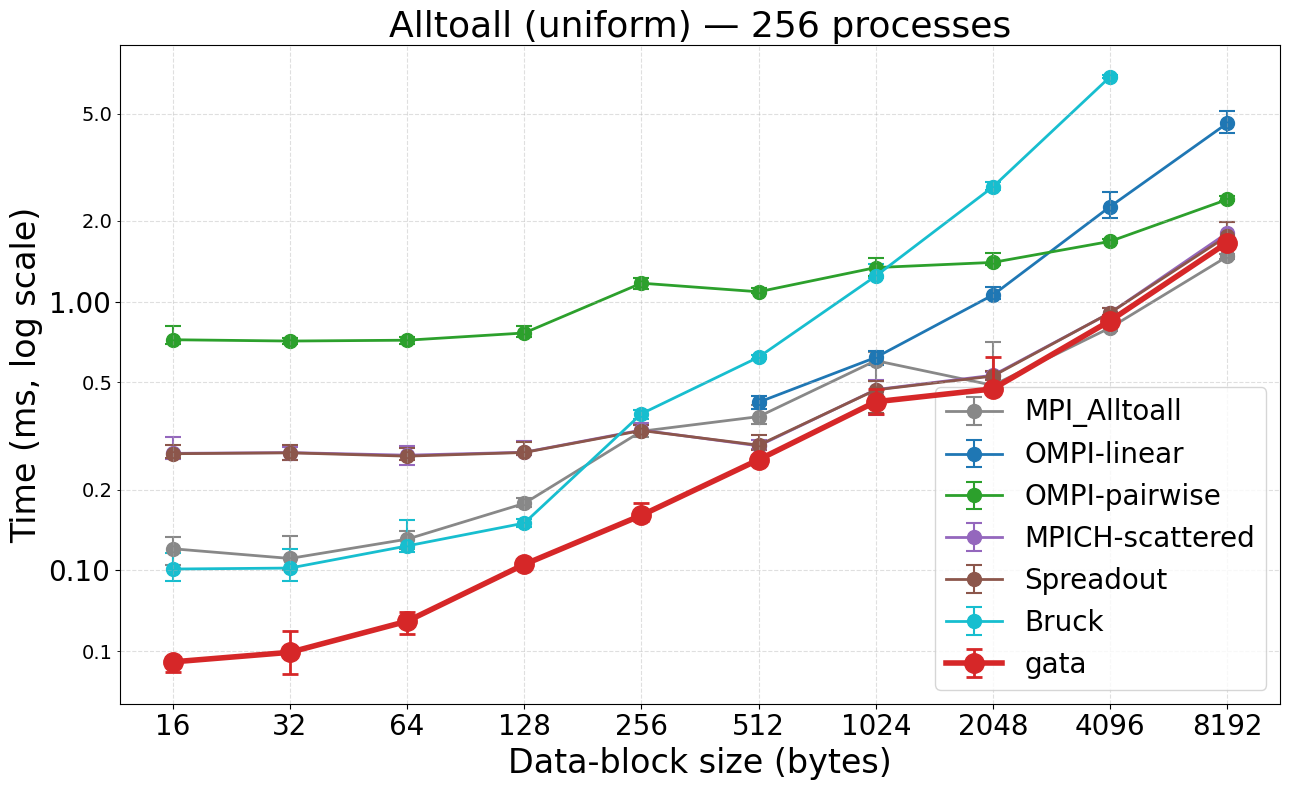

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2     256        0.27252       0.260019       0.313448
         4     256       0.274349       0.256876       0.286857
         8     256       0.268311       0.246901       0.289612
        16     256        0.27514       0.269588        0.30417
        32     256       0.332724       0.327695       0.354675
        64     256       0.290639       0.282057       0.306402
       128     256       0.470526       0.379739       0.511589
       256     256       0.531873       0.514964       0.546093
       512     256       0.907234        0.87958       0.946895
      1024     256        1.79897        1.70676        1.97656

Best gata parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b       r     median(ms)         lo(ms)         hi(ms)
----------------

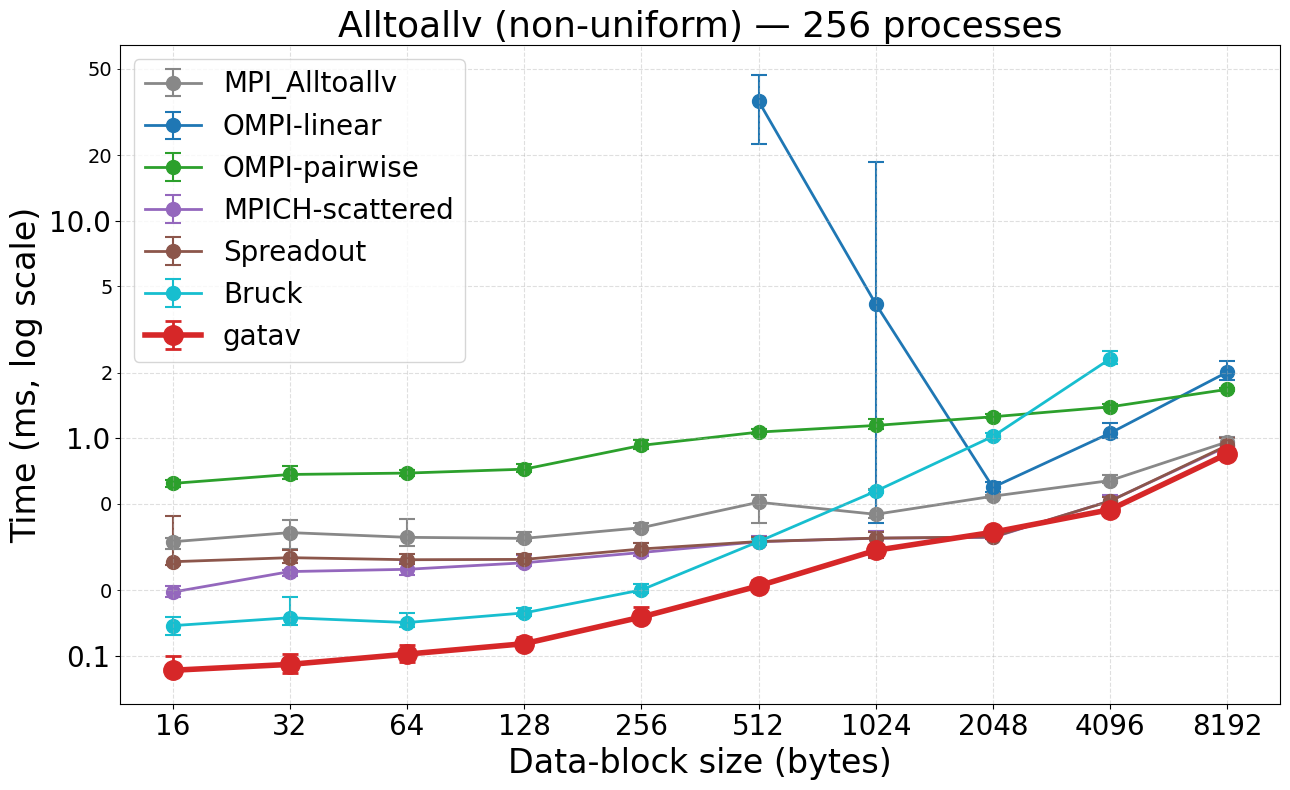

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2     256       0.195967       0.185087       0.208842
         4     256       0.243497       0.231895       0.247657
         8     256       0.249417       0.234318       0.270357
        16     256       0.267248       0.259531       0.290051
        32     256       0.298013       0.287188        0.33101
        64     256       0.334247       0.322457        0.35661
       128     256       0.346658        0.28302       0.372399
       256     256       0.349706       0.344115       0.357109
       512     256        0.51471       0.501921       0.546614
      1024     128       0.917415       0.872003        1.00287

Best gatav parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b       r     median(ms)         lo(ms)         hi(ms)
---------------

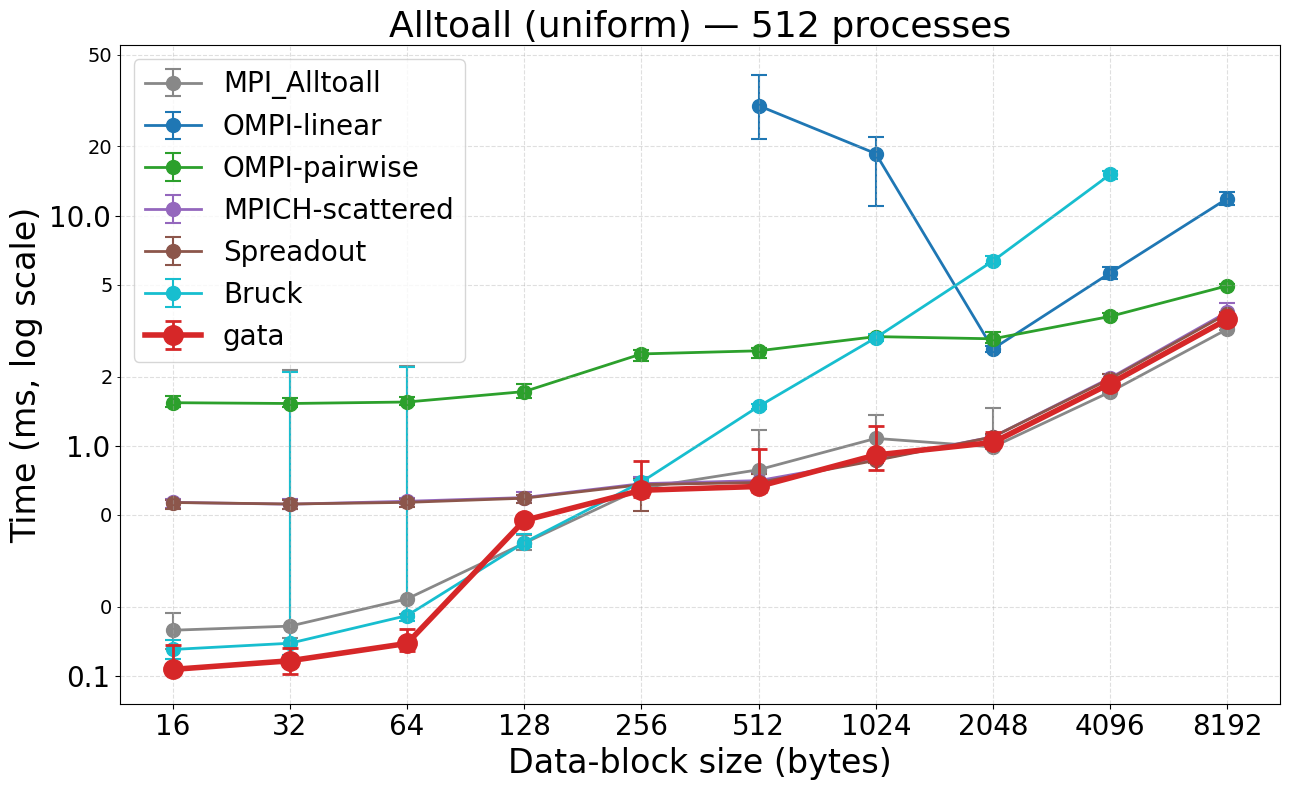

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2     512       0.567563       0.534216       0.584866
         4     512       0.556984       0.529956       0.588584
         8     512       0.573551       0.558178       0.592119
        16     512       0.595278       0.585696       0.631552
        32     512       0.684109       0.660489       0.733608
        64     512       0.705223       0.684654       0.768873
       128     512       0.869454       0.848851       0.895288
       256     512        1.09299        1.06627        1.11243
       512     512        1.96996        1.90528        2.05913
      1024     512        3.81233         3.6527        4.17827

Best gata parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b       r     median(ms)         lo(ms)         hi(ms)
----------------

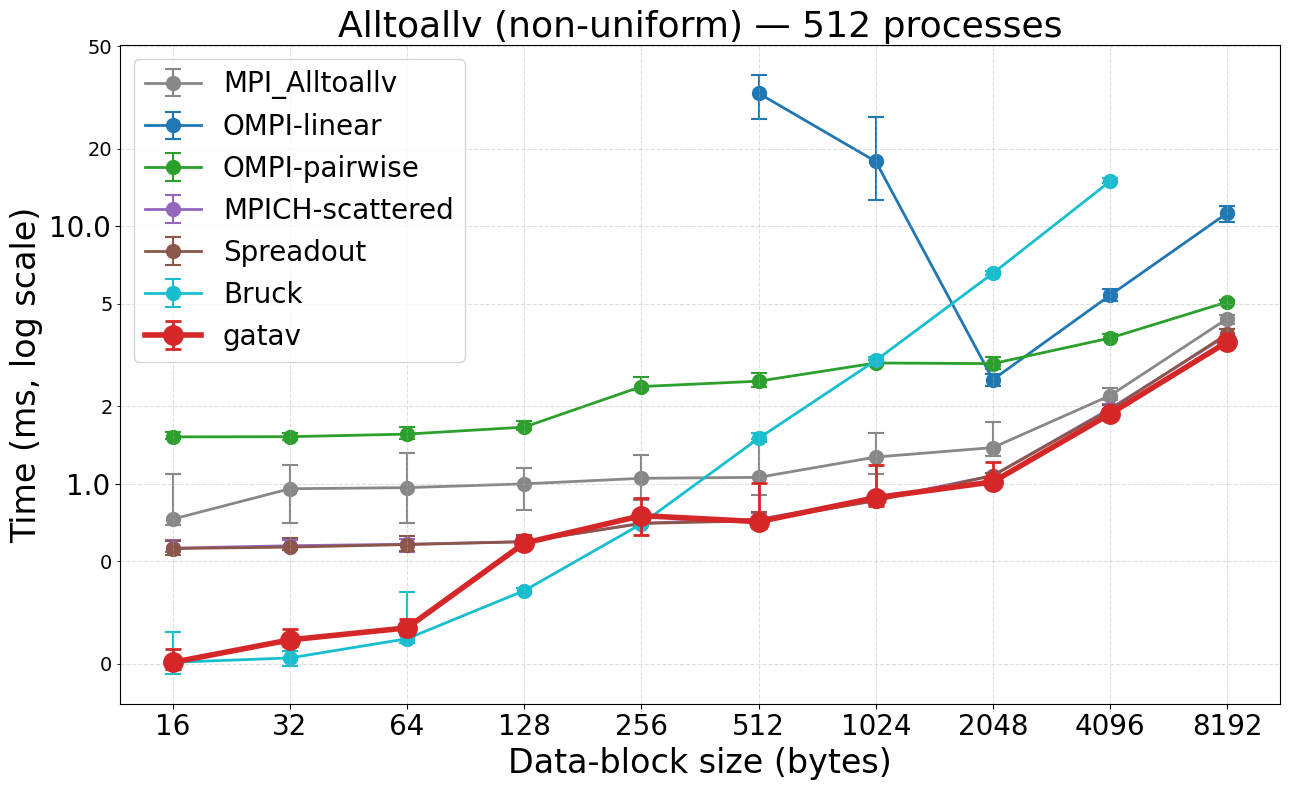

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2     512       0.562955        0.54595       0.607199
         4     512         0.5754       0.552864       0.608111
         8     512       0.583077       0.545531        0.61213
        16     512       0.596901       0.561944       0.626737
        32     512       0.703825       0.689962       0.763453
        64     512       0.729876       0.716502        0.77184
       128     512       0.869486       0.851225         0.9125
       256     256        1.07726        1.05824        1.10432
       512     512        1.95922        1.91117         2.0491
      1024     512        3.77536        3.64846        3.97846

Best gatav parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b       r     median(ms)         lo(ms)         hi(ms)
---------------

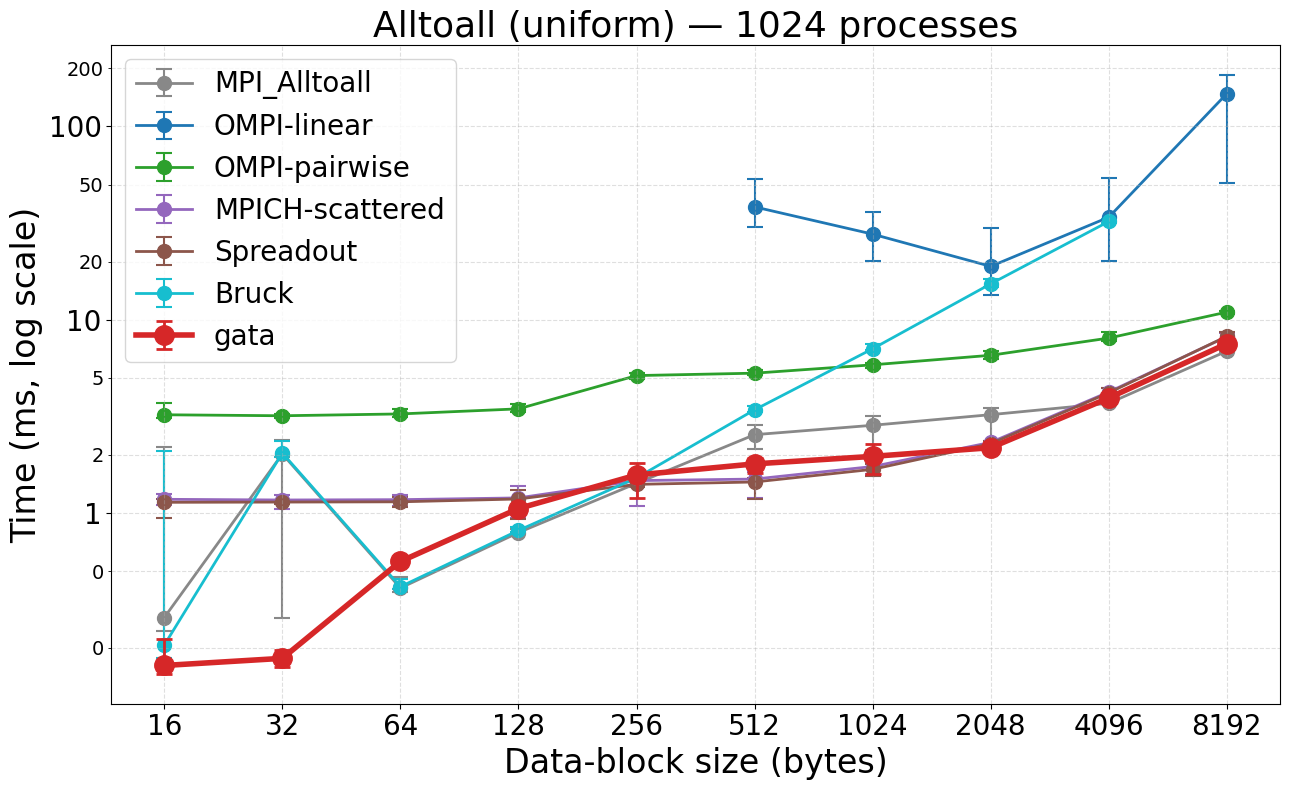

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2    1024        1.17572         1.1039        1.25008
         4    1024          1.166        1.04447        1.23215
         8    1024        1.17071        1.08619        1.23892
        16    1024        1.19541       0.939039        1.38061
        32    1024        1.46937        1.08693        1.55807
        64    1024        1.49637        1.19325        1.62462
       128     256        1.73791        1.58569        1.92176
       256     512        2.31653        2.27536        2.36854
       512     512        4.22455        4.11641        4.41584
      1024    1024        8.17502        7.82172         8.5391

Best gata parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b       r     median(ms)         lo(ms)         hi(ms)
----------------

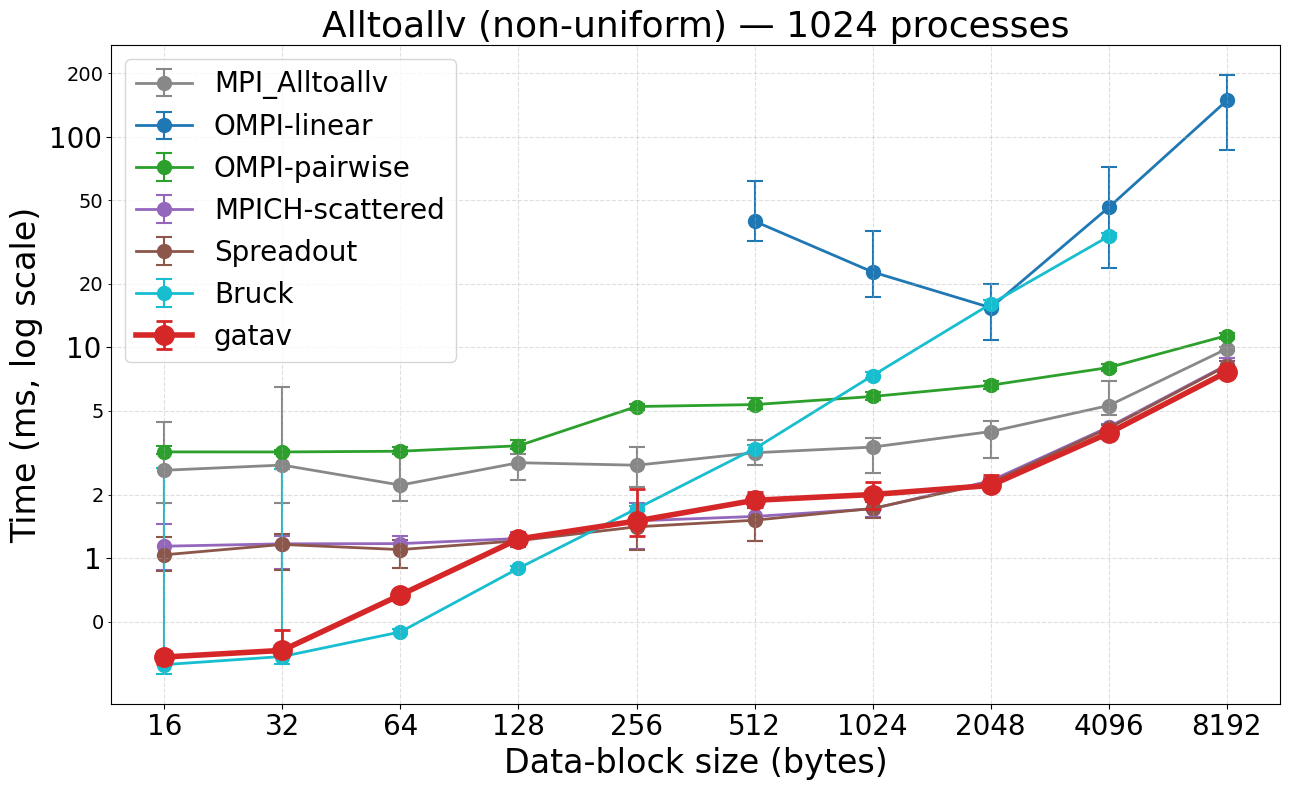

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2    1024        1.13869       0.878477        1.44813
         4    1024        1.16868        0.89106        1.27186
         8    1024         1.1712       0.901382        1.26782
        16    1024        1.23866        1.19021        1.33268
        32    1024        1.50218        1.10562        1.83555
        64     512        1.57614         1.2035        1.72601
       128     256        1.71271        1.57408        1.96788
       256     512        2.32789        2.28486        2.40897
       512     512        4.19211        4.10391        4.33813
      1024     512        8.25634        7.83946        8.93362

Best gatav parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b       r     median(ms)         lo(ms)         hi(ms)
---------------

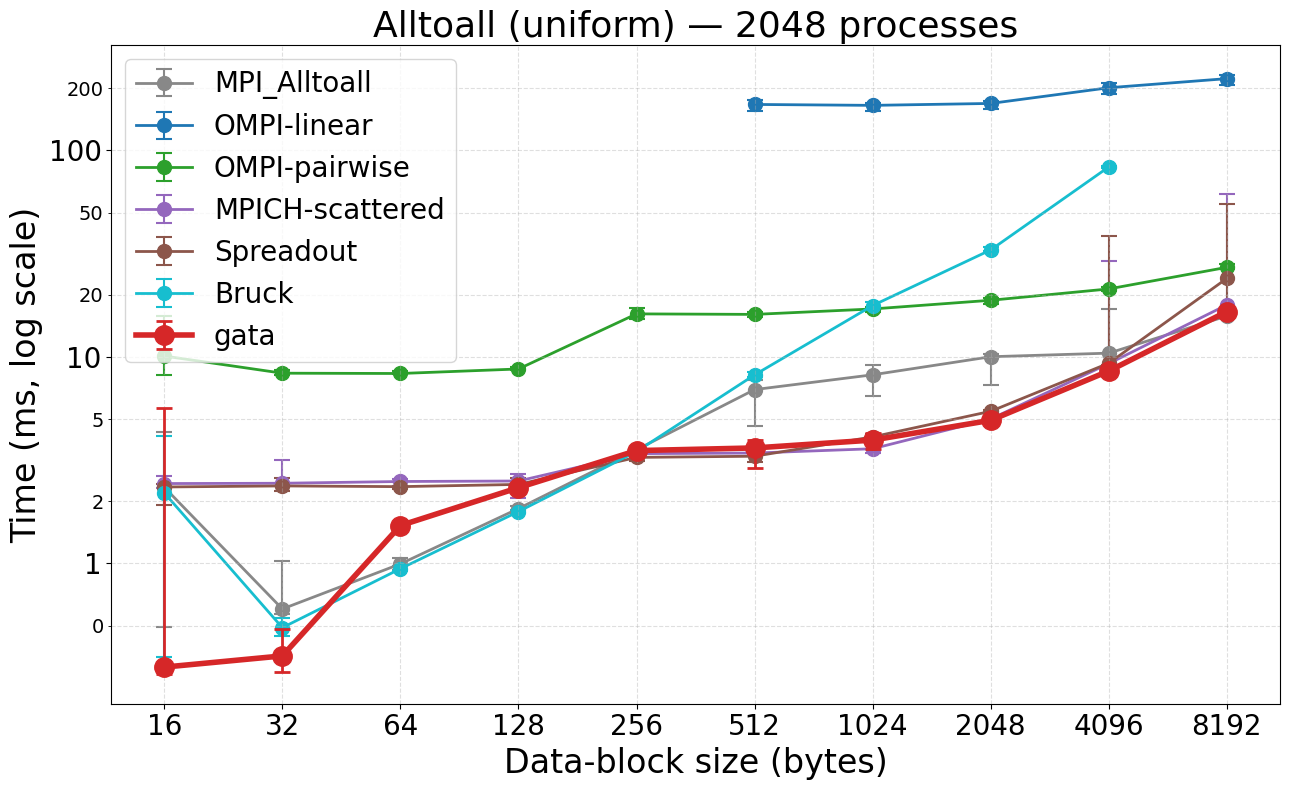

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2    2048        2.43735         2.3235        2.64178
         4    2048         2.4453        2.36847        3.15519
         8    2048        2.49369        2.38156         2.5722
        16    1024        2.50744        2.06558        2.72167
        32      32        3.40189        3.29259        3.60353
        64      32        3.42424        3.34551        3.58684
       128     512        3.59268        3.41398        4.02165
       256     128        5.00522        4.93773        5.17026
       512    1024        9.28321        9.03342        29.1385
      1024    2048        17.8596         16.971        61.7387

Best gata parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b       r     median(ms)         lo(ms)         hi(ms)
----------------

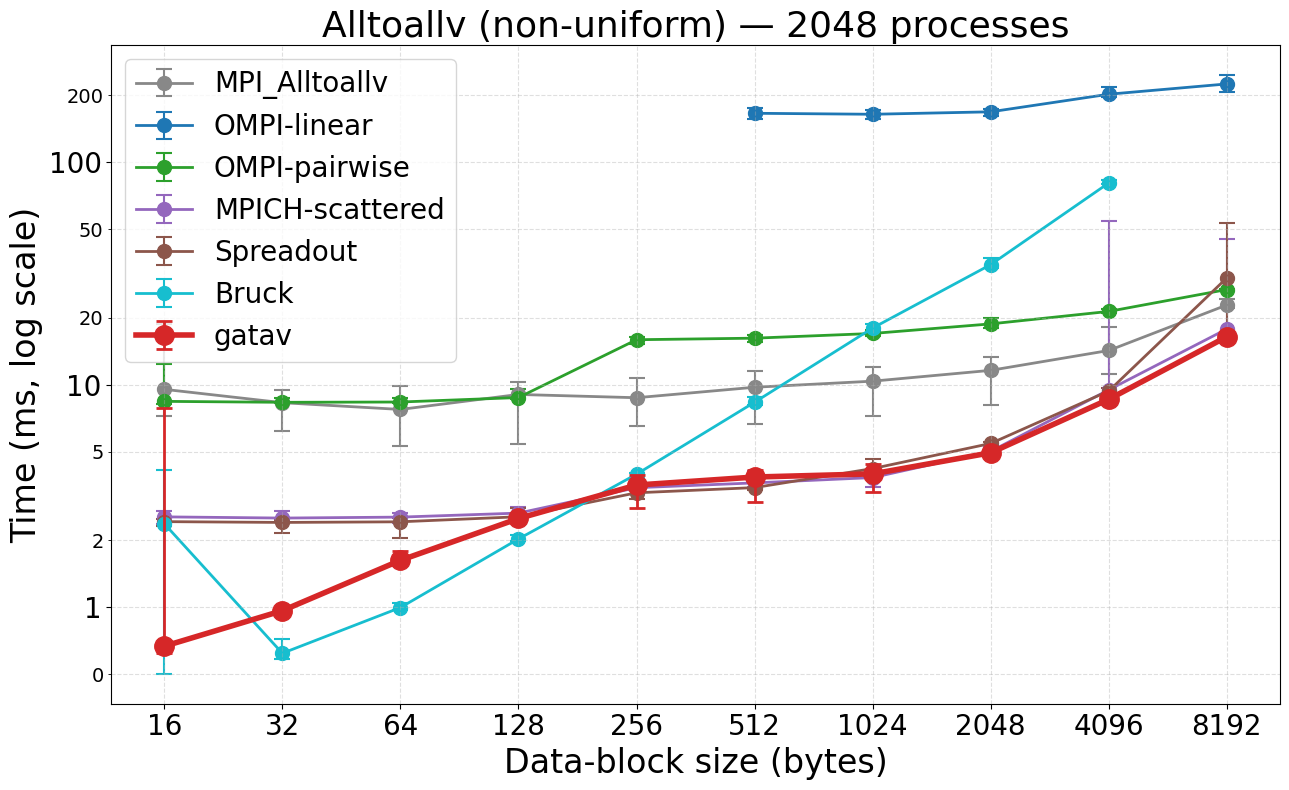

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2    2048        2.55307        2.37255          2.701
         4    2048        2.52158        2.42469        2.71931
         8    2048        2.54673        2.40722         2.6679
        16    2048        2.65447        2.56555        2.82849
        32    2048        3.45232        3.36933        3.64261
        64      32        3.62823        3.47888        4.10488
       128     512        3.83471        3.46219        4.08849
       256     128        5.02759        4.97752        5.25205
       512    1024        9.50524        9.02203        54.3651
      1024    2048        17.8405        16.8626        45.1354

Best gatav parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b       r     median(ms)         lo(ms)         hi(ms)
---------------

In [9]:
def _file_nprocs(path):
    """Extract nprocs from a 'run_<N>.sh.o<JOBID>' filename for sorting."""
    m = re.search(r'run_(\d+)', os.path.basename(path))
    return int(m.group(1)) if m else 0


files = sorted(glob.glob(DATA_GLOB), key=_file_nprocs)
print(f'Found {len(files)} result file(s):')
for f in files:
    print(f'  {os.path.basename(f)}')


def process_file(path):
    base = os.path.basename(path)
    print('\n' + '=' * 70)
    print(f'FILE: {base}')
    print('=' * 70)

    ata_data, atav_data, nprocs_seen = parse_combined(path)
    if not nprocs_seen:
        print('(no benchmark lines)'); return
    nprocs = next(iter(nprocs_seen))

    # ata
    print(f'\n--- ata, {nprocs} processes ---')
    plot(ata_data,  'ata',  nprocs, save_to=f'gata_{nprocs}.png')
    print_best_table(ata_data, 'MPICH-scattered', ('b',))
    print()
    print_best_table(ata_data, 'gata', ('b', 'r'))

    # atav
    print(f'\n--- atav, {nprocs} processes ---')
    plot(atav_data, 'atav', nprocs, save_to=f'gatav_{nprocs}.png')
    print_best_table(atav_data, 'MPICH-scattered', ('b',))
    print()
    print_best_table(atav_data, 'gatav', ('b', 'r'))


for f in files:
    process_file(f)